# **IAPR26: UNO Vision Challenge**


**Group Name :** 

**Author 1 (sciper):** Arno Douady (326395)  
**Author 2 (sciper):** Nicolas Robson (325334)   
**Author 3 (sciper):** Johanne Pinel (324707)   

**Release date:** 24.04.2026   
**Due date:** 20.05.2026 (11:55 pm)


In [3]:
# From past Labs

from skimage.color import rgb2hsv
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation
from skimage.transform import rotate, resize, AffineTransform, warp
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import matplotlib.image as mpimg


import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from src.Project_utils import *

from sklearn.metrics import accuracy_score, f1_score

In [4]:
# Check dans quel dossier on est
print(os.getcwd())

c:\Users\Johanne\Desktop\EPFL\MA4\Image pattern\iapr2026\Project


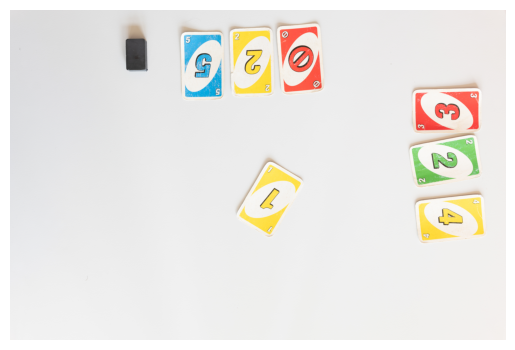

In [5]:
# Printer une image
img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000770.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

## Fist step : Segmentation

Extraire les cartes --> hmmm peut être faire 5 images : une pour le jaune, une pour le rouge, une pour le bleu et une pour le vert et une dernière pour le noir ?

In [6]:
def extract_hsv_channels(img):
    """
    Extract HSV channels from the input image.

    """
    # Get the shape of the input image
    M, N, C = np.shape(img)

    # Define default values for HSV channels
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    data_hsv = rgb2hsv(img)
    data_h = data_hsv[:, :, 0]
    data_s = data_hsv[:, :, 1]
    data_v = data_hsv[:, :, 2]
    # print(np.min(data_h), np.max(data_h))
    # print(np.min(data_s), np.max(data_s))
    # print(np.min(data_v), np.max(data_v))
    
    return data_h, data_s, data_v

In [7]:
def apply_hsv_threshold(img, h_thresh=0.1, s_thresh=0.1, v_thesh=0.1):
    """
    Apply threshold to the input image in hsv colorspace.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    h_thresh: float
        Hue value threshold
    s_thresh: float
        Saturation value threshold
    v_thresh: float
        Value threshold
    
    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract HSV channels
    data_h, data_s, data_v = extract_hsv_channels(img=img)
    
    # ------------------
    # Your code here ... 
    # ------------------
    img_th = (data_h > h_thresh) & (data_s > s_thresh) & (data_v > v_thesh)
    
    return  img_th

    

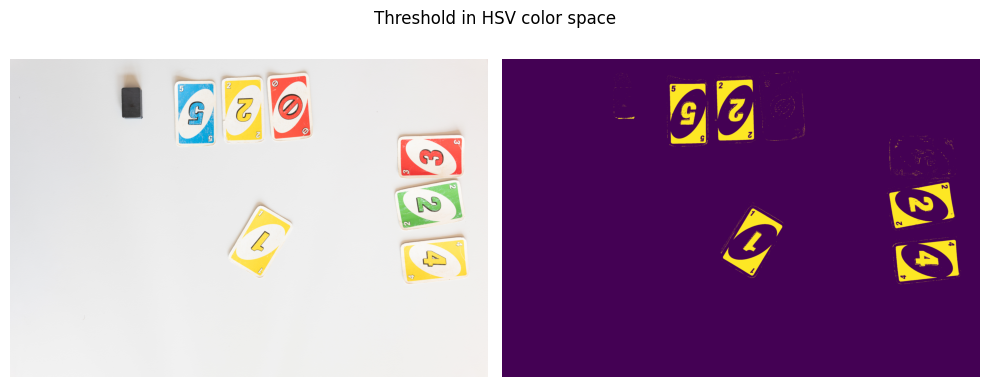

In [8]:
img_th=apply_hsv_threshold(img)
plot_thresholded_image(img=img, func=apply_hsv_threshold, title="Threshold in HSV color space")

Pas zinzin hsv j'arrive pas à faire les plots comme dans le tp ça run pendant mille ans

In [9]:
def extract_rgb_channels(img):
    # Get the shape of the input image
    M, N, _ = np.shape(img)

    # Define default values for RGB channels
    data_red = np.zeros((M, N))
    data_green = np.zeros((M, N))
    data_blue = np.zeros((M, N))

    # ------------------
    # Your code here ... 
    data_red = img[:, :, 0]
    data_green = img[:, :, 1]
    data_blue = img[:, :, 2]
    # ------------------
    
    return data_red, data_green, data_blue

In [ ]:
def apply_rgb_threshold(img):
    """
    Apply threshold to input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract RGB channels
    data_red, data_green, data_blue = extract_rgb_channels(img=img)
    
    # ------------------
    # Your code here ... 
    # ------------------
    img_th = (data_red > 150) & (data_green > 200) & (data_blue > 100)

    
    return  img_red

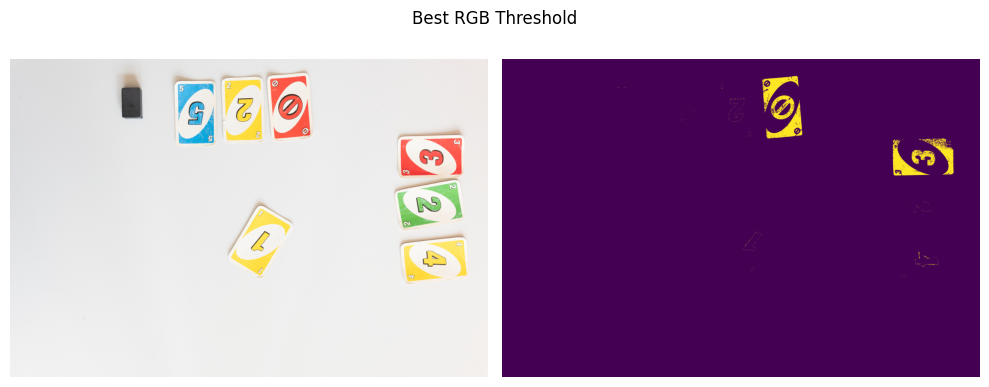

In [11]:
plot_thresholded_image(img=img, func=apply_rgb_threshold, title="Best RGB Threshold")

### Faire comme dernier exo du lab 1 pour décomposer les différents éléments

Est-ce que avoir le channel en noir --> avoir direct la position du joueur/joueuse ?


In [13]:
def apply_closing(img_th, disk_size):

    img_closing = np.zeros_like(img_th)

    
    img_closing = closing(img_th, disk(disk_size))


    return img_closing



In [38]:
def apply_rgb_threshold_v2(img, mode="red"):

    r, g, b = extract_rgb_channels(img)


    if mode == "red":
        img_th = (r > 100) & (g < 100) & (b < 100) #test carte rouge

        
    elif mode == "blue":
        img_th = (r < 100) & (g < 50) & (b > 80)
                 
    elif mode == "green":
        # Vert dominant: G élevé, R et B faibles
        r_min, r_max = 0.0, 0.4
        g_min, g_max = 0.5, 1.0
        b_min, b_max = 0.0, 0.5
        

            
    elif mode == "yellow":
        # Jaune: R et G élevés, B faible
        r_min, r_max = 0.6, 1.0
        g_min, g_max = 0.6, 1.0
        b_min, b_max = 0.0, 0.4

            
    elif mode == "black":

            threshold = 0.25
            img_th = (r <= threshold) & (g <= threshold) & (b <= threshold)


    

    return img_th

def find_area_by_type(
    img: np.ndarray,
    mode: str = "red",
    visualize_hsv: bool = False,
    visualize_mask: bool = False,
    disk_size: int = 3,
    object_min_size: int = 30,
):

    if visualize_hsv:
        plot_colors_histo(
            img=img,
            func=extract_rgb_channels,
            labels=["R", "G", "B"],
        )

    img_th = apply_rgb_threshold_v2(img, mode=mode)

    if visualize_mask:
        plot_thresholded_image(
            img=img,
            func=lambda img: apply_rgb_threshold_v2(img, mode=mode),
            title=f"{mode.capitalize()} detection in HSV space"
        )

    out_mask = apply_closing(img_th, disk_size)

    return out_mask

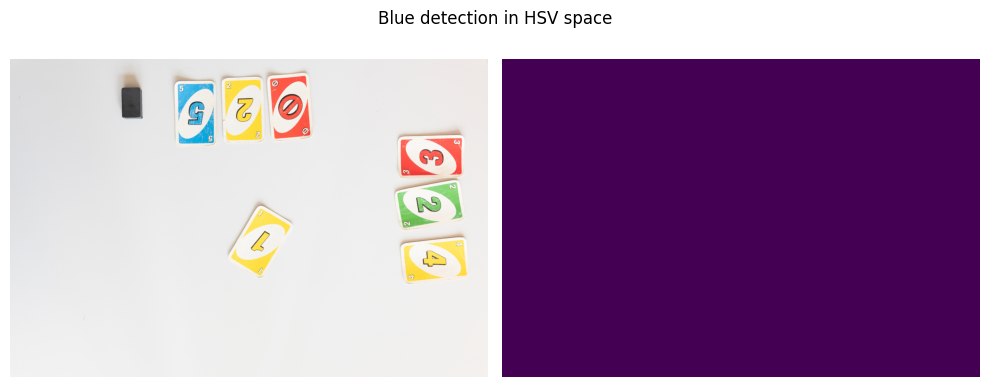

In [39]:
M, N, C= np.shape(img)
mask_red = np.zeros((M, N))
mask_blue = np.zeros((M, N))

# Note, disk size and minimum kept object size can be called explicitly in find_area_by_type

#mask_red = find_area_by_type(img, mode="red", visualize_mask=True)
mask_blue = find_area_by_type(img, mode="blue", visualize_mask=True)